In [1]:
library(org.Hs.eg.db)
library(clusterProfiler)

Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: Biobase

Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, see
    'citation("Biobase")', and for packages 'citation("pkgname")'.


Loading required package: IRanges

Loading required package: S4Vectors

In [2]:
library(ggplot2)

In [3]:
library(dplyr)
library(stringr)
library(simplifyEnrichment)


Attaching package: ‘dplyr’


The following object is masked from ‘package:AnnotationDbi’:

    select


The following objects are masked from ‘package:IRanges’:

    collapse, desc, intersect, setdiff, slice, union


The following objects are masked from ‘package:S4Vectors’:

    first, intersect, rename, setdiff, setequal, union


The following object is masked from ‘package:Biobase’:

    combine


The following objects are masked from ‘package:BiocGenerics’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: grid



In [ ]:
library(tidyverse)

In [ ]:
DoGO <- function(gene_id){
    data_go <- enrichGO(gene = 
                             gene_id,
                             OrgDb = org.Hs.eg.db,
                             ont = "BP",
                             pAdjustMethod = "BH",
                             qvalueCutoff = 0.05,
                             pvalueCutoff = 0.05,
                             readable = TRUE
                        )
    return(data_go)
}

In [ ]:
DoKEGG <- function(gene_id){
 #   gene_id = data$geneId
    data_kegg <- enrichKEGG(gene        = gene_id,
                         organism     = 'hsa',
                          qvalueCutoff = 0.05,
                         pvalueCutoff = 0.05)
    for(i in 1:nrow(data_kegg@result)){
        data_kegg@result$geneID[i]  %>% str_split('/')  %>% .[[1]] ->a
        a2 <- bitr(a, fromType="ENTREZID", toType="SYMBOL", OrgDb="org.Hs.eg.db")
        paste0(a2$SYMBOL ,collapse = '/') -> a3
        data_kegg@result$geneID[i] <- a3
}
    return(data_kegg)
}

In [ ]:
prepare <- function(C2_go,C3_go){
    C2_go  %>% as.data.frame() -> C2_temp
    C3_go  %>% as.data.frame() -> C3_temp
    C2_temp  %>% dplyr::select(Description,GeneRatio,p.adjust,Count,geneID) %>% 
    mutate(group = "C2") -> C2_temp2
    C3_temp  %>% dplyr::select(Description,GeneRatio,p.adjust,Count,geneID)  %>% 
        mutate(Description=Description,group = "C3") -> C3_temp2
    if(nrow(C2_temp2)>20){
        C2_temp2 = C2_temp2[1:20,]
    }else if(nrow(C2_temp2)>0){
        C2_temp2 = C2_temp2[1:nrow(C2_temp2),]
    }else{
        C2_temp2 = C2_temp
    }

    if(nrow(C3_temp2)>15){
        C3_temp2 = C3_temp2[1:20,]
    }else if(nrow(C3_temp2)>0){
        C3_temp2 = C3_temp2[1:nrow(C3_temp2),]
    }else{
        C3_temp2 = C3_temp
    }
    rbind(C2_temp2,C3_temp2) -> C2_C3_comb

    C2_C3_comb$logP <- -log10(C2_C3_comb$p.adjust)

    C2_C3_comb  %>% mutate(logP=ifelse(group=='C2',-logP,logP)) -> C2_C3_comb

    C2_C3_comb  %>% arrange((logP)) -> C2_C3_comb

    C2_C3_comb$Description <- factor(C2_C3_comb$Description,levels=unique(C2_C3_comb$Description))

    for(i in 1:nrow(C2_C3_comb)){
        C2_C3_comb$geneID[i]  %>%  str_split('/')  %>% .[[1]]  %>% 
            paste(collapse = ', ') -> C2_C3_comb$geneID[i]
        
    }
    return(C2_C3_comb)
}


In [ ]:
C2_gene_isct <- readRDS(file = "C2geneid_mergeGeneBody_HiChIP_isctRNAseq.Rds")
C3_gene_isct <- readRDS(file = "C3geneid_mergeGeneBody_HiChIP_isctRNAseq.Rds")

In [ ]:
length(C2_gene_isct)

In [ ]:
length(C3_gene_isct)

In [ ]:
C2_isct_kegg <- DoKEGG(C2_gene_isct)
C3_isct_kegg <- DoKEGG(C3_gene_isct)

In [ ]:
C2_isct_go <- DoGO(C2_gene_isct)
C3_isct_go <- DoGO(C3_gene_isct)

In [28]:
saveRDS(C2_isct_kegg ,'C2_isct_kegg.FC1.5.genebody.Rds')
saveRDS(C3_isct_kegg ,'C3_isct_kegg.FC1.5.genebody.Rds')

In [15]:
active_mat_C2 = GO_similarity(C2_isct_go %>% as.data.frame() %>% rownames(),ont="BP")
active_mat_C3 = GO_similarity(C3_isct_go %>% as.data.frame() %>% rownames(),ont="BP")

In [16]:
pdf(file ="GO_simplify_C2_isct_RNA_hichip_heatmap.pdf" ,width = 9,height = 6)
df_act_C2 = simplifyGO(active_mat_C2)
dev.off()

Cluster 241 terms by 'binary_cut'...
 19 clusters, used 0.6958778 secs.

Perform keywords enrichment for 16 GO lists...



png 
  2

In [17]:
pdf(file ="GO_simplify_C3_isct_RNA_hichip_heatmap.pdf" ,width = 9,height = 6)
df_act_C2 = simplifyGO(active_mat_C3)
dev.off()

Cluster 252 terms by 'binary_cut'...
 13 clusters, used 0.822705 secs.

Perform keywords enrichment for 7 GO lists...



png 
  2

In [18]:
openxlsx::write.xlsx(list(C2GO=as.data.frame(C2_isct_go),C3GO=as.data.frame(C3_isct_go)),rowNames = TRUE, 
                     file = "GO.ATACgenebodyandHiChiP.isct_RNAseq.FC1.5.xlsx")

In [19]:
openxlsx::write.xlsx(list(C2GO=as.data.frame(C2_isct_kegg),C3GO=as.data.frame(C3_isct_kegg)),rowNames = TRUE, 
                     file = "KEGG.ATACgenebodyandHiChiP.isct_RNAseq.FC1.5.xlsx")

In [29]:
plot_go <- function(C2_C3_GO){
    ### bar oplot
   C2_C3_GO <- C2_C3_GO %>%
      arrange(group, logP) %>% 
      mutate(Description = factor(Description, levels = unique(Description)))

    # Create the plot
    p1 <- ggplot(C2_C3_GO, aes(x = logP, y = Description, fill = group)) + 
      geom_col() + 
   #   scale_fill_manual(values = c('#e57373', "#4e87c6")) +
      theme_bw()

    # Define theme
    mytheme <- theme(
      axis.text.y = element_blank(),
      axis.ticks.y = element_blank(),
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      panel.border = element_blank(),
      axis.line.x = element_line(color = 'black')
    )

    # Add GO description text, ensuring the order remains consistent
    p2 <- p1 + mytheme +
      geom_text(aes(x = ifelse(group == "C3", -0.05, 0.05), 
                    y = Description, 
                    label = Description), 
                size = 6, hjust = ifelse(C2_C3_GO$group == "C3", 1, 0))
#    ### add  gene names 
#    p3 <- p2 +mytheme+
#    geom_text(data = C3_desc,aes(x = 0.05, y = Description, label = geneID),size = 5,color='black',hjust = 0) +
#    geom_text(data = C2_desc,aes(x = -0.05, y = Description, label = geneID),color='black',size = 5,hjust = 1) 
    ### add dashlines
  #  p2 <- p2 +geom_hline(yintercept = seq(1, length(unique(C2_C3_comb$Description))) - 0.5, 
  #                       color = 'gray', linetype = 'dashed')
    p2 <- p2 + scale_fill_manual(values = c( "#ca0020","#0571b0"))
    return(p2)
}

In [56]:
C2_isct_kegg  %>% as.data.frame()%>%.[,'geneID'] %>% str_split('/')  %>% unlist()  %>% unique() %>% length()

[1] 40

In [57]:
C3_isct_kegg %>% as.data.frame()%>% .[,'geneID'] %>% str_split('/')  %>% unlist()  %>% unique() %>% length()

[1] 111

In [31]:
C2_C3_KEGG <- prepare(C2_isct_kegg,C3_isct_kegg)

In [32]:
C2_C3_GO <- prepare(C2_isct_go,C3_isct_go)

In [33]:
p_KEGG <- plot_go(C2_C3_KEGG)

In [34]:
p_GO <- plot_go(C2_C3_GO)

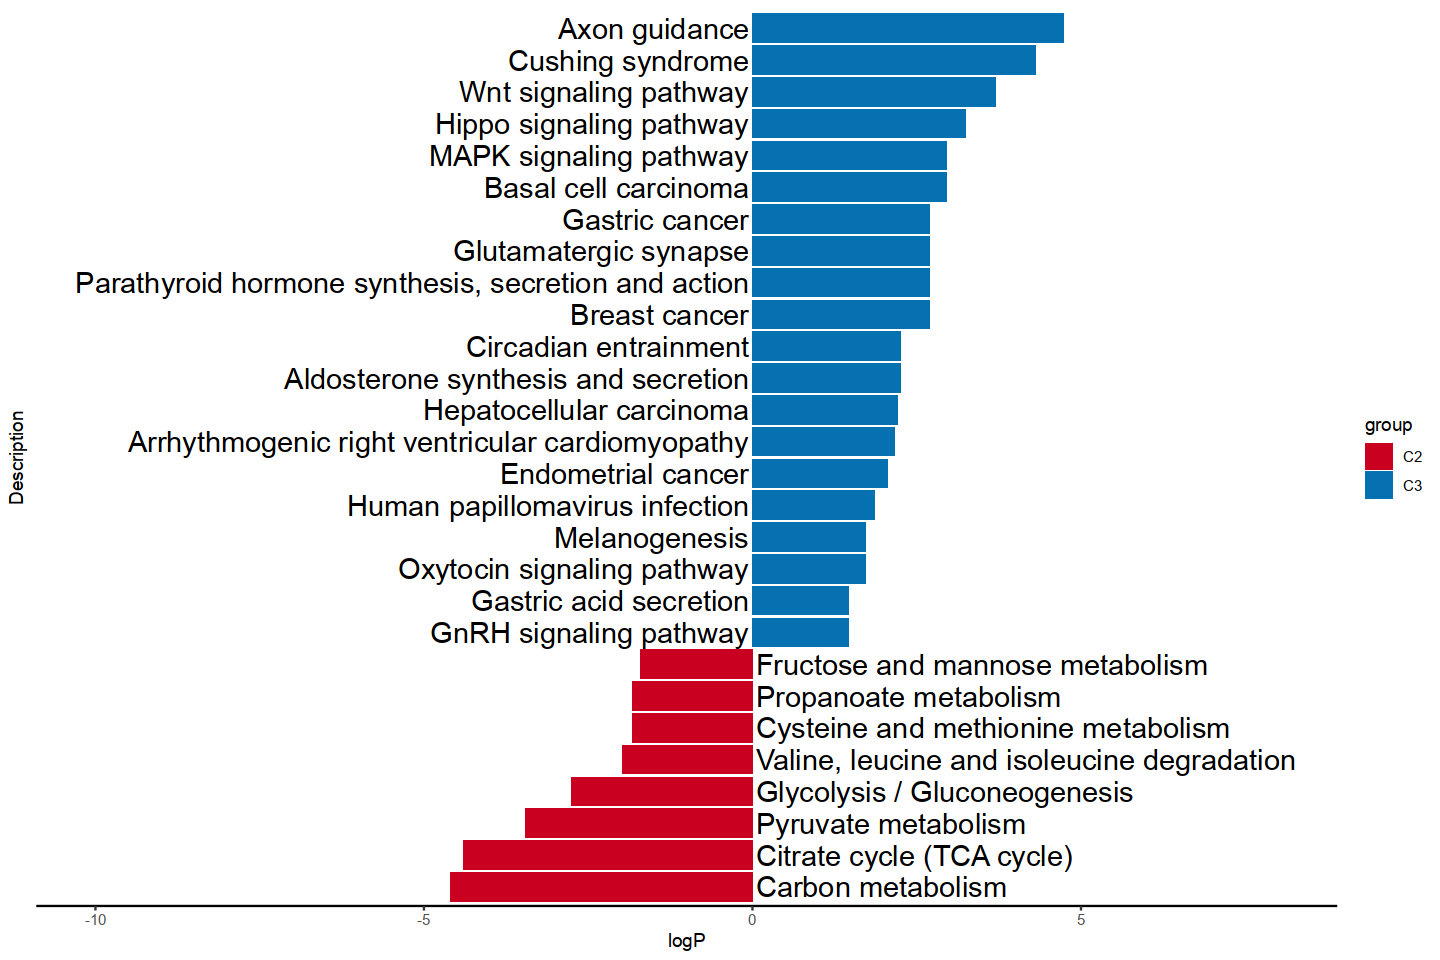

In [35]:
options(repr.plot.height=8,repr.plot.width=12)
p_KEGG+xlim(-10,8)

In [36]:
ggsave(filename = "KEGGall_combine.Bar.pdf",plot = p_KEGG+xlim(-10,8),width = 12,height = 8)

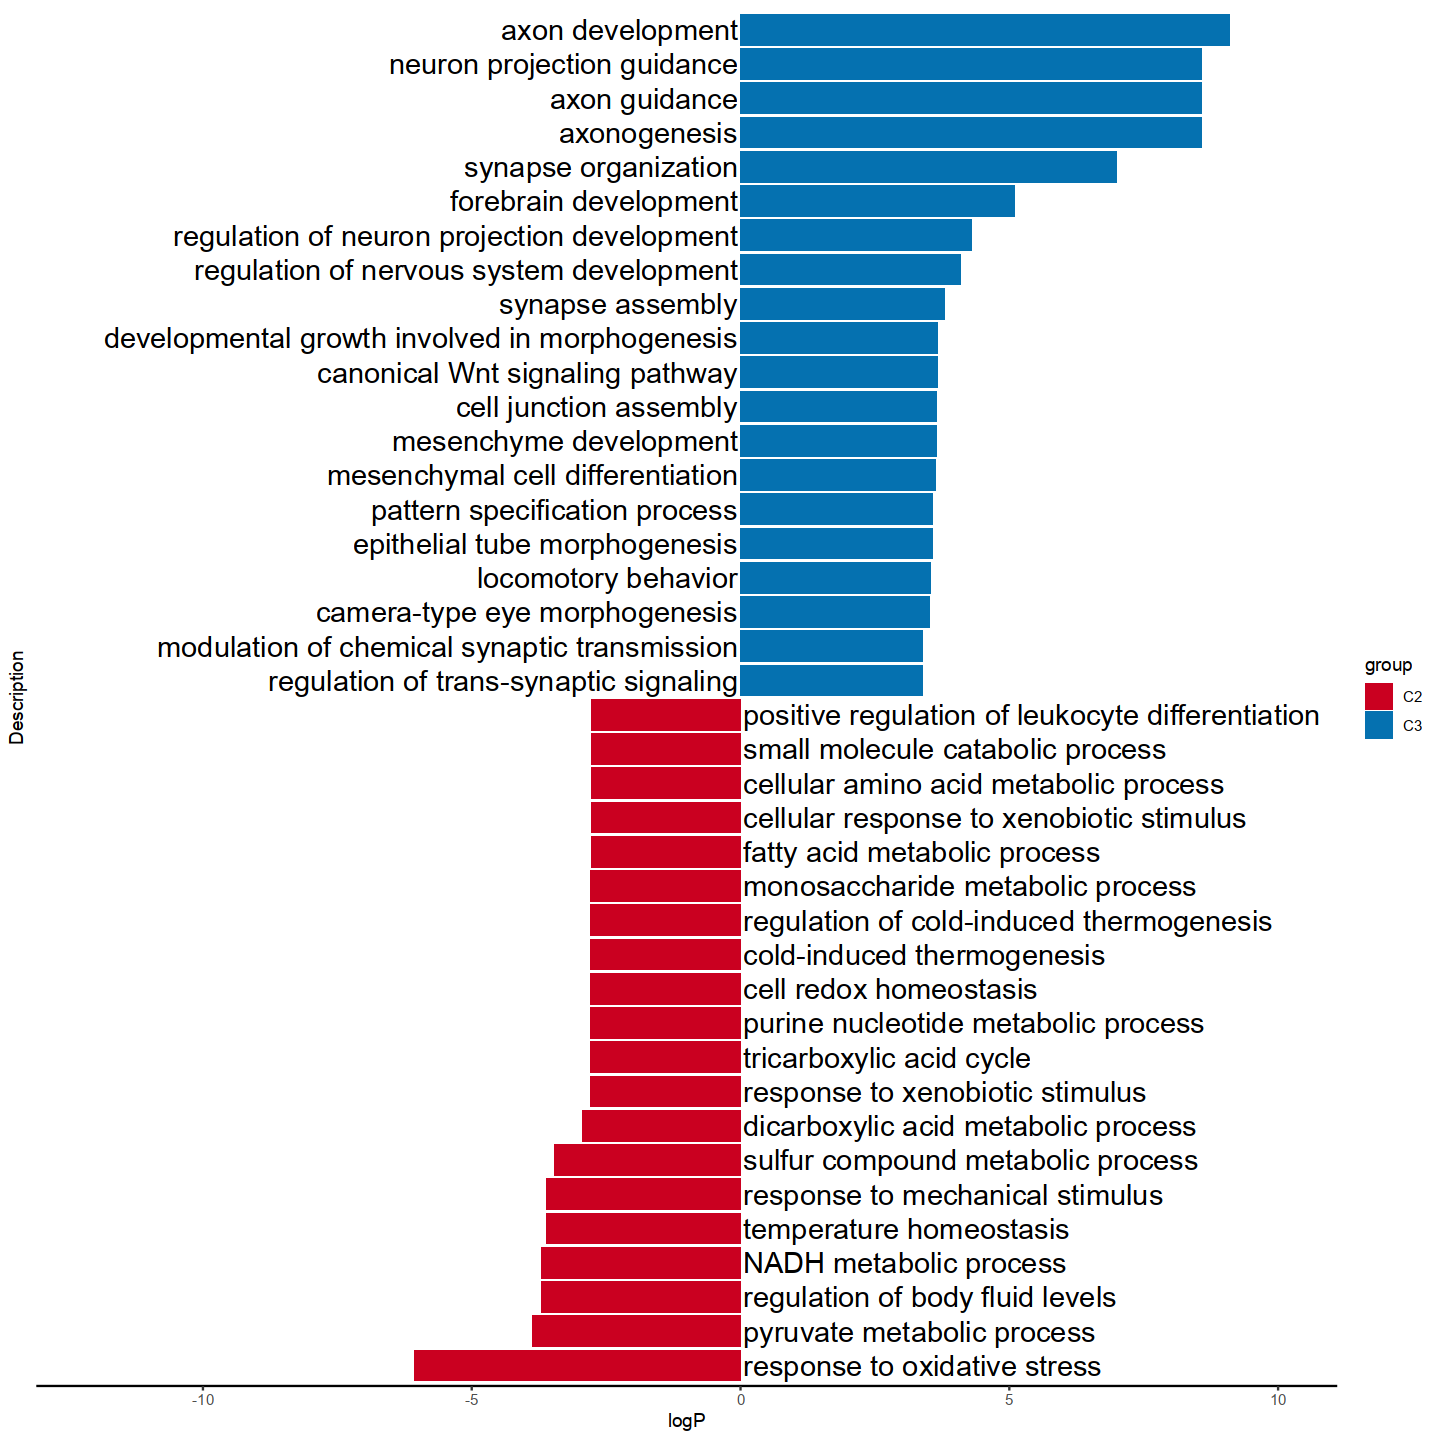

In [37]:
options(repr.plot.height=12,repr.plot.width=12)
p_GO+xlim(-12,10)

In [38]:
ggsave(filename = "GOtop20_combine.Bar.pdf",plot = p_GO+xlim(-12,10),width = 12,height = 12)

In [39]:
save.image('GO_annotation_RNA-ATAC_isct.Rds')

In [1]:
load('GO_annotation_RNA-ATAC_isct.Rds')



Registered S3 methods overwritten by 'treeio':
  method              from    
  MRCA.phylo          tidytree
  MRCA.treedata       tidytree
  Nnode.treedata      tidytree
  Ntip.treedata       tidytree
  ancestor.phylo      tidytree
  ancestor.treedata   tidytree
  child.phylo         tidytree
  child.treedata      tidytree
  full_join.phylo     tidytree
  full_join.treedata  tidytree
  groupClade.phylo    tidytree
  groupClade.treedata tidytree
  groupOTU.phylo      tidytree
  groupOTU.treedata   tidytree
  is.rooted.treedata  tidytree
  nodeid.phylo        tidytree
  nodeid.treedata     tidytree
  nodelab.phylo       tidytree
  nodelab.treedata    tidytree
  offspring.phylo     tidytree
  offspring.treedata  tidytree
  parent.phylo        tidytree
  parent.treedata     tidytree
  root.treedata       tidytree
  rootnode.phylo      tidytree
  sibling.phylo       tidytree

